# Machine Learning and Data Mining
## Capstone Project – XR Learning Assistant

Structured according to Tasks 1–5.

#Machine Learning and Data Mining Capstone Portfolio.
This notebook discusses all the 5 tasks in the Track A brief. Instead of making each part a separate exercise, the aim was to develop to a coherent runtime system one in which regression, classification, clustering, association rules and anomaly detection are all feeding one decision loop capable of reacting dynamically to what a learner is doing.

The data includes session-level data on an XR learning environment. A row reflects the interaction with the system of a learner within a session: the duration of active time, the frequency of requesting help, the types of modalities they utilized, the more recent history of quiz attempts, and the neediness. support required is the target of classification, next quiz score is regression.

Some preliminary remarks before getting into it. The brief only requests k-fold CV on the training split - the validation and test sets are reserved until the appropriate time. Preprocessing is performed with scikit-learn Pipelines to avoid leakage. The dataset is splitted using the predefined split column instead of random split.

# Task 1: Regression – Predicting Next Quiz Score

#Step 1 — Importing libraries
All the requirements of the entire project are imported in advance. Having everything on one place implies that it is easier to look at dependencies at a glance and the notebook can be executed top-to-bottom in a new Colab session, without needing to search for missing packages.

Some that are worth noting in particular: Pipeline and ColumnTransformer scikit-learn have are necessary to keep preprocessing within the cross-validation loop - this is how data leakage is avoided. Task 2 requires CalibratedClassifierCV since the raw classifier probabilities are not usually well calibrated and the threshold analysis relies on well calibrated probabilities. mlxtend provides the Apriori implementation of association rule mining in Task 3.

In [33]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import roc_auc_score
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_classif
from sklearn.model_selection import KFold, cross_validate
from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.ensemble import RandomForestRegressor,RandomForestClassifier,IsolationForest
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.cluster import KMeans
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,classification_report,
    silhouette_score,davies_bouldin_score
)
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.base import clone

from mlxtend.frequent_patterns import apriori, association_rules

import joblib

Random_State=42
CV_Folds=5

#Step 2 — Data loading the dataset.
 This is to ensure that the CSV loads, and the shape and column names are correct, and to ensure the existence of the split column and its proper filling. The split was predefined instead of arbitrary to ensure that the results can be reproduced and that the sessions of the same learner are not randomly distributed between training and test sets.

In [34]:
DATA_PATH = "/content/xr_learner_sessions.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())

print("\nAll column names:")
print(df.columns.tolist())

print("\nRows per split:")
print(df["split"].value_counts(dropna=False))

Dataset shape: (2662, 35)


,session_id,learner_id,session_index,session_start_iso,day_of_week,time_of_day,days_since_prev_session,device_type,input_mode,accessibility_nonvoice_enabled,...,dominant_modality,prev_quiz_mean,prev_quiz_last,prev_quiz_attempts,prior_mastery_level,confidence_rating,next_quiz_score,time_to_mastery_days,support_required,split
0,S_0000001,L_0001,1,2026-01-12T20:45:06,Mon,Evening,NaN,AR_Tablet,HandTracking,1,...,Practice,NaN,NaN,0,0.3921,1,52.8,21.69,0,val
1,S_0000002,L_0001,2,2026-01-15T19:46:19,Thu,Evening,2.96,AR_Tablet,Mixed,0,...,Practice,52.80,52.8,1,0.4955,2,57.9,20.53,0,val
2,S_0000003,L_0001,3,2026-01-20T16:38:13,Tue,Afternoon,4.87,VR_HMD,HandTracking,1,...,Practice,55.35,57.9,2,0.5261,3,59.4,17.07,1,val
3,S_0000004,L_0001,4,2026-01-22T13:57:47,Thu,Afternoon,1.89,VR_HMD,Gaze,1,...,Practice,56.70,59.4,3,0.5560,2,61.3,15.81,0,val
4,S_0000005,L_0001,5,2026-01-27T13:42:16,Tue,Afternoon,4.99,AR_Tablet,Voice,1,...,Practice,57.85,61.3,4,0.5523,3,57.5,21.33,0,val



All column names:
['session_id', 'learner_id', 'session_index', 'session_start_iso', 'day_of_week', 'time_of_day', 'days_since_prev_session', 'device_type', 'input_mode', 'accessibility_nonvoice_enabled', 'avg_latency_ms', 'tracking_loss_ratio', 'session_duration_min', 'attention_ratio', 'active_time_ratio', 'pause_count', 'help_request_count', 'hint_time_sec', 'error_count', 'completion_rate', 'video_count', 'reading_count', 'audio_count', 'practice_count', 'modality_switches', 'dominant_modality', 'prev_quiz_mean', 'prev_quiz_last', 'prev_quiz_attempts', 'prior_mastery_level', 'confidence_rating', 'next_quiz_score', 'time_to_mastery_days', 'support_required', 'split']

Rows per split:
split
train    1859
val       446
test      357
Name: count, dtype: int64


#Basic structural preprocessing.
This step takes care of some few things that must be done before any other thing: parsing the column of timestamps, extracting hour and day features out of it, and verifying the presence of duplicates. This is due to the fact that timestamp parsing is not a transformation that needs to be trained on training data, i.e. it is a deterministic transformation. Hour of day, day of month can record some very fine changes in learning (evening classes, weekly classes) that would otherwise be lost by simply eliminating the timestamp.

This step does not include imputation, scaling, and encoding and does not intend to. This is because those operations can only be learnt using training data and, therefore, they are part of a Pipeline that is fit into each fold of cross-validation.

In [35]:
data = df.copy()

# Parse the ISO timestamp string into a proper datetime object
data["session_start_iso"] = pd.to_datetime(data["session_start_iso"], errors="coerce")

# Extract temporal features that might capture learning rhythm effects
data["session_hour"] = data["session_start_iso"].dt.hour
data["session_month"] = data["session_start_iso"].dt.month
data["session_day"] = data["session_start_iso"].dt.day

dup_count = data.duplicated().sum()
print("Duplicate rows found:", dup_count)

if dup_count > 0:
    data = data.drop_duplicates()
    print("Duplicates removed.")

print("Shape after basic preprocessing:", data.shape)
display(data.head())

Duplicate rows found: 0
Shape after basic preprocessing: (2662, 38)


,session_id,learner_id,session_index,session_start_iso,day_of_week,time_of_day,days_since_prev_session,device_type,input_mode,accessibility_nonvoice_enabled,...,prev_quiz_attempts,prior_mastery_level,confidence_rating,next_quiz_score,time_to_mastery_days,support_required,split,session_hour,session_month,session_day
0,S_0000001,L_0001,1,2026-01-12 20:45:06,Mon,Evening,NaN,AR_Tablet,HandTracking,1,...,0,0.3921,1,52.8,21.69,0,val,20,1,12
1,S_0000002,L_0001,2,2026-01-15 19:46:19,Thu,Evening,2.96,AR_Tablet,Mixed,0,...,1,0.4955,2,57.9,20.53,0,val,19,1,15
2,S_0000003,L_0001,3,2026-01-20 16:38:13,Tue,Afternoon,4.87,VR_HMD,HandTracking,1,...,2,0.5261,3,59.4,17.07,1,val,16,1,20
3,S_0000004,L_0001,4,2026-01-22 13:57:47,Thu,Afternoon,1.89,VR_HMD,Gaze,1,...,3,0.5560,2,61.3,15.81,0,val,13,1,22
4,S_0000005,L_0001,5,2026-01-27 13:42:16,Tue,Afternoon,4.99,AR_Tablet,Voice,1,...,4,0.5523,3,57.5,21.33,0,val,13,1,27


#Missing value checking.
There are no random gaps in this dataset, it is structural. Columns such as prev_quiz_mean, prev_quiz_last, and days since previous session are blank when it comes to learners that are taking their first appearance since there really is no history to rely on. This is important because the elimination of such rows would automatically exclude first-session learners in the analysis, skewing the results of conclusions regarding the time of need to provide support.

The dealing with these gaps strategy is median imputation within the pipeline. The mean is more sensitive to outliers than the median and in these two characteristics the distribution is not symmetric enough to render the imputation of the mean a default that is safe.

# Task 2: Classification – Predicting Support Requirement

In [36]:
missing_counts = data.isnull().sum()
missing_pct = (missing_counts / len(data)) * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing_counts,
    "Missing %": missing_pct
}).sort_values(by="Missing %", ascending=False)

# Only show columns that actually have missing values
display(missing_summary[missing_summary["Missing Count"] > 0])

,Missing Count,Missing %
prev_quiz_last,360,13.523666
days_since_prev_session,360,13.523666
prev_quiz_mean,360,13.523666


### Output Interpretation: Missing Value Summary

This output reports how many missing values exist in each feature.

It identifies incomplete variables and whether missing data handling is necessary before modelling.
If missing values are present, imputation becomes necessary because many machine learning models cannot work with null entries directly.
This output justifies the preprocessing design used later in the notebook.


## Defining target and feature columns.
This notebook has two tasks of prediction running in parallel. Next, the regression target is next_quiz_score giving the tutor a quantitative idea of the direction the learner is heading in the short run. The classification target is support needed, which is a binary variable that influences the decisions about interventions.

There are a number of columns that should not be included in the feature set. Such identifiers as session-id and learner-id do not contain a generalisable signal - they are specific to particular records. Derived features have already been substituted with the raw timestamp. Split column is only to delineate partitions of data. And both target variables should be held out to prevent leakage: allowing the model to see the answer during training would give artificially optimistic measures that would not generalise to new data.

In [37]:
target_reg = "next_quiz_score"
target_clf = "support_required"

# Columns excluded from the feature set for various reasons (see markdown above)
drop_cols = [
    "session_id",
    "learner_id",
    "session_start_iso",
    "split",
    target_reg,
    target_clf
]

feature_cols = [col for col in data.columns if col not in drop_cols]

print("Regression target:", target_reg)
print("Classification target:", target_clf)
print("Number of features:", len(feature_cols))
print(feature_cols)

Regression target: next_quiz_score
Classification target: support_required
Number of features: 32
['session_index', 'day_of_week', 'time_of_day', 'days_since_prev_session', 'device_type', 'input_mode', 'accessibility_nonvoice_enabled', 'avg_latency_ms', 'tracking_loss_ratio', 'session_duration_min', 'attention_ratio', 'active_time_ratio', 'pause_count', 'help_request_count', 'hint_time_sec', 'error_count', 'completion_rate', 'video_count', 'reading_count', 'audio_count', 'practice_count', 'modality_switches', 'dominant_modality', 'prev_quiz_mean', 'prev_quiz_last', 'prev_quiz_attempts', 'prior_mastery_level', 'confidence_rating', 'time_to_mastery_days', 'session_hour', 'session_month', 'session_day']


## The separation of categorical and numerical columns.
The various types of features require various preprocessing. The median is imputed in numerical columns and standardised. Categorical columns are imputed to the most common value and then one-hot encoded. It would be wrong to run the same transformation on both types, as averaging a device type label would not give meaningful results, and would also mislead any model that would expect numeric inputs.

The programmatic detection of such types (instead of a hard-coded one) makes the code more resilient to any future modifications in the schema of the dataset.

In [38]:
X_all = data[feature_cols]

categorical_cols = X_all.select_dtypes(include=["object", "category"]).columns.tolist()
numerical_cols = X_all.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()

print("Categorical columns:")
print(categorical_cols)
print("\nNumerical columns:")
print(numerical_cols)

Categorical columns:
['day_of_week', 'time_of_day', 'device_type', 'input_mode', 'dominant_modality']

Numerical columns:
['session_index', 'days_since_prev_session', 'accessibility_nonvoice_enabled', 'avg_latency_ms', 'tracking_loss_ratio', 'session_duration_min', 'attention_ratio', 'active_time_ratio', 'pause_count', 'help_request_count', 'hint_time_sec', 'error_count', 'completion_rate', 'video_count', 'reading_count', 'audio_count', 'practice_count', 'modality_switches', 'prev_quiz_mean', 'prev_quiz_last', 'prev_quiz_attempts', 'prior_mastery_level', 'confidence_rating', 'time_to_mastery_days', 'session_hour', 'session_month', 'session_day']


# Exploratory data analysis
This is the part of knowing the data prior to making any modelling decisions. Three of them can be worth inspecting in specific: the regression target distribution shape, the classification target balance, and the correlation structure among numeric features.

The next-quiz-score should have a normative target, which implies that the standard measures of regression will provide an accurate view of performance. Large imbalance in the support required would imply that raw accuracy is a false measure - a model that predicts that no support is needed would be considered highly accurate but of no usefulness. And correlation analysis may show what features are likely to dominate predictions, which is a useful context to understand model results in the future.

Dataset structure:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2662 entries, 0 to 2661
Data columns (total 38 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   session_id                      2662 non-null   object        
 1   learner_id                      2662 non-null   object        
 2   session_index                   2662 non-null   int64         
 3   session_start_iso               2662 non-null   datetime64[ns]
 4   day_of_week                     2662 non-null   object        
 5   time_of_day                     2662 non-null   object        
 6   days_since_prev_session         2302 non-null   float64       
 7   device_type                     2662 non-null   object        
 8   input_mode                      2662 non-null   object        
 9   accessibility_nonvoice_enabled  2662 non-null   int64         
 10  avg_latency_ms                  2662 non-null   float

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
session_id,2662,2662,S_0002662,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
learner_id,2662,360,L_0356,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
session_index,2662.0,NaN,NaN,NaN,4.744929,1.0,2.0,4.0,7.0,12.0,2.849857
session_start_iso,2662,NaN,NaN,NaN,2025-12-12 03:47:54.703982080,2025-09-16 10:24:25,2025-11-07 12:40:50.750000128,2025-12-09 17:45:07,2026-01-18 14:09:01.249999872,2026-03-15 19:46:21,NaN
day_of_week,2662,7,Mon,388,NaN,NaN,NaN,NaN,NaN,NaN,NaN
time_of_day,2662,4,Evening,1113,NaN,NaN,NaN,NaN,NaN,NaN,NaN
days_since_prev_session,2302.0,NaN,NaN,NaN,4.023193,-0.57,2.7,3.91,5.19,10.84,2.004653
device_type,2662,3,VR_HMD,1460,NaN,NaN,NaN,NaN,NaN,NaN,NaN
input_mode,2662,5,Controllers,700,NaN,NaN,NaN,NaN,NaN,NaN,NaN
accessibility_nonvoice_enabled,2662.0,NaN,NaN,NaN,0.553343,0.0,0.0,1.0,1.0,1.0,0.49724


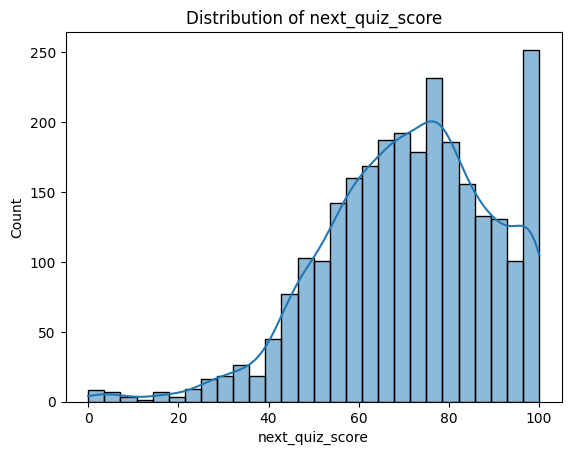

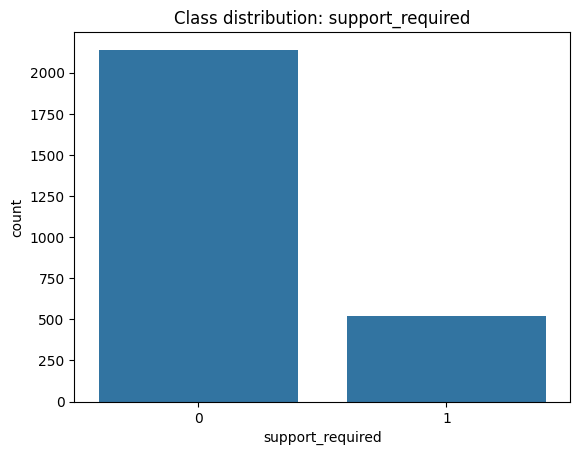

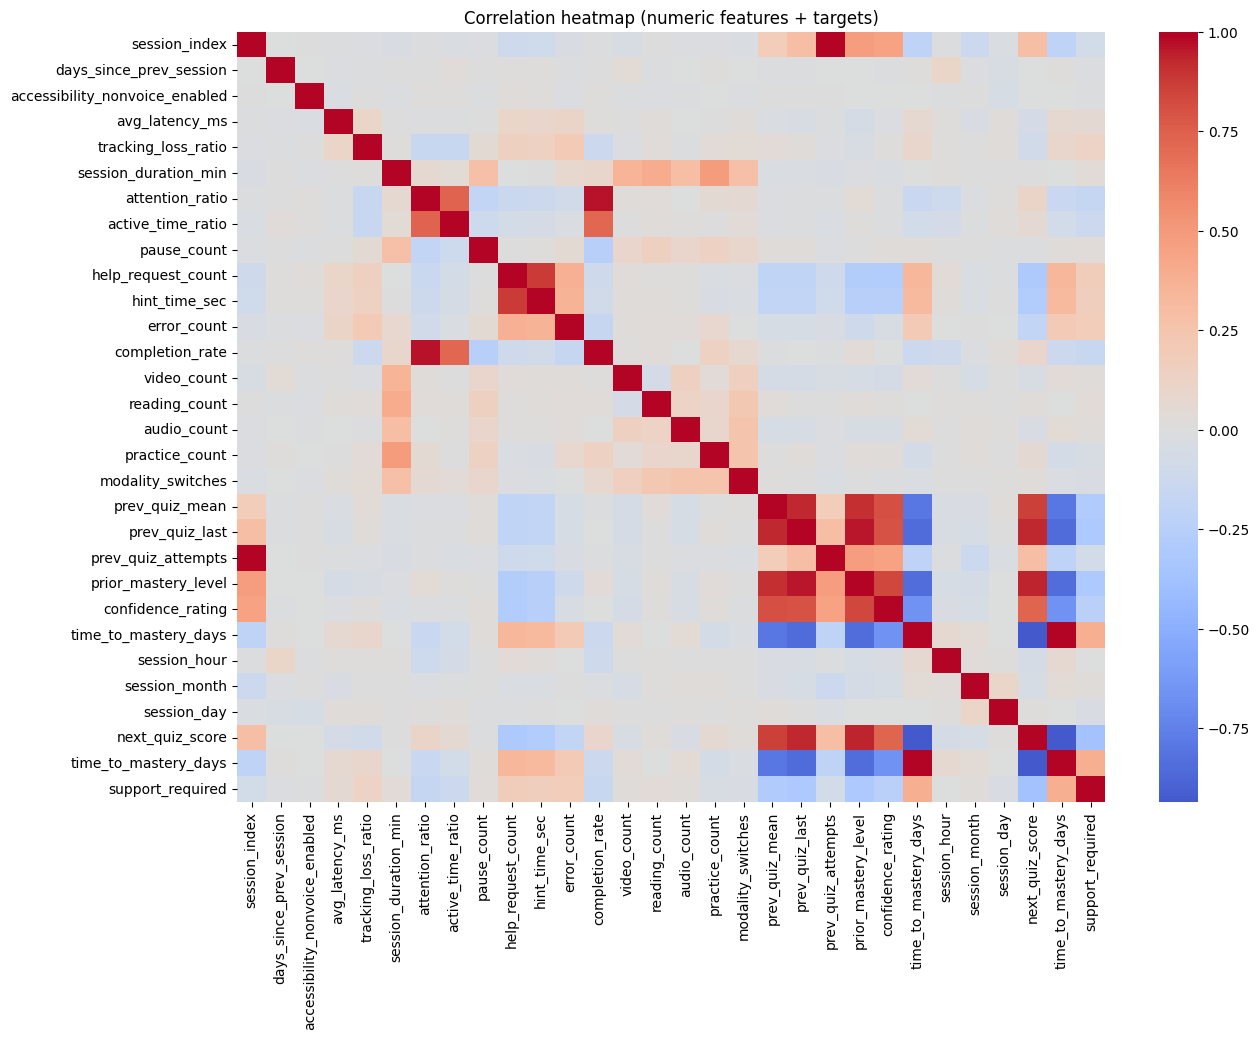

In [39]:
print("Dataset structure:")
print(data.info())

print("\nDescriptive statistics:")
display(data.describe(include="all").T)

# How is the regression target distributed?
plt.figure()
sns.histplot(data[target_reg], kde=True)
plt.title("Distribution of next_quiz_score")
plt.show()



# Is the classification target balanced?
plt.figure()
sns.countplot(x=data[target_clf])
plt.title("Class distribution: support_required")
plt.show()

# Correlation heatmap to identify dominant linear predictors
corr_cols = numerical_cols + [target_reg, "time_to_mastery_days", target_clf]
corr_cols = [c for c in corr_cols if c in data.columns]

plt.figure(figsize=(14, 10))
corr = data[corr_cols].corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation heatmap (numeric features + targets)")
plt.show()

### Output Interpretation: Exploratory Data Analysis

These outputs provide the first evidence about the structure and behaviour of the dataset.


Typical outputs here include:
- dataset shape and column types
- summary statistics
- target distributions
- correlation heatmaps


These outputs help identify whether variables are balanced, skewed, potentially related, or likely to need preprocessing.
EDA is important because later modelling choices should be based on observed data properties rather than guesswork.


# Task 3: Clustering, Association, and Anomaly Detection

##  Building the preprocessing pipeline

This cell defines the preprocessing logic used before model training. Numerical variables are imputed with the median and standardised, while categorical variables are imputed with the most frequent category and converted into one-hot encoded indicators. These two branches are then combined into a single ColumnTransformer.

The dataset contains mixed feature types, and most machine learning models require numeric, non-missing inputs. Without a structured preprocessing pipeline, the modelling stage would either fail or become inconsistent across train, validation, and test sets.

Median imputation is more robust than mean imputation when numeric features may be skewed. Standardisation is helpful because several algorithms are sensitive to feature scale. One-hot encoding was chosen for categorical variables because it preserves category identity without imposing a false ranking between values.

Mean imputation was not prioritised because it can be distorted by outliers. Label encoding was avoided because it would suggest ordinal relationships that do not exist. Manual preprocessing outside a pipeline was also rejected because it increases the risk of leakage and makes the workflow harder to reproduce.


In [40]:
# Numeric path: fill gaps with the median, then standardise
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical path: fill gaps with the most common value, then one-hot encode
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine into a single transformer that handles both column types
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numerical_cols),
    ("cat", categorical_transformer, categorical_cols)
])

print("Preprocessor built and ready.")

Preprocessor built and ready.


##  Using the predefined train, validation, and test split


This cell separates the full dataset into training, validation, and test subsets using the existing `split` column, then builds the feature matrices and target vectors for the regression and classification tasks.

A reliable machine learning workflow must separate model fitting, model selection, and final evaluation. The training set is used to fit models, the validation set is used to compare and tune them, and the test set is reserved for the final unbiased performance check.

The predefined split was respected because it preserves the experimental structure already provided in the dataset. This improves reproducibility and avoids introducing a different partitioning logic that might unintentionally change the difficulty of the task.

A new random split was not created because the dataset already contains an explicit split column. Re-randomising would add unnecessary variation and weaken the justification for reproducible evaluation.


In [41]:
# Use the predefined split column — do not re-randomise
train_df = data[data["split"] == "train"].copy()
val_df   = data[data["split"] == "val"].copy()
test_df  = data[data["split"] == "test"].copy()

X_train = train_df[feature_cols]
y_reg_train = train_df[target_reg]
y_clf_train = train_df[target_clf]

X_val = val_df[feature_cols]
y_reg_val = val_df[target_reg]
y_clf_val = val_df[target_clf]

X_test = test_df[feature_cols]
y_reg_test = test_df[target_reg]
y_clf_test = test_df[target_clf]

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (1859, 32)
Validation shape: (446, 32)
Test shape: (357, 32)


##  Feature selection design

This cell sets up feature selection separately for regression and classification. SelectKBest is used with f_regression for the continuous target and mutual_info_classif for the binary support target. It also defines the number of cross-validation folds and other shared experiment settings.

After one-hot encoding, the number of features can increase considerably. Feature selection helps control dimensionality, reduce noise, and focus the models on the most informative variables.

f_regression is suitable for measuring the relationship between transformed features and a continuous outcome, while mutual_info_classif is appropriate for classification because it can detect non-linear dependence rather than only simple linear effects. This makes the selection strategy better aligned with each prediction task.

Recursive feature elimination and exhaustive wrapper methods were not prioritised because they are more computationally expensive and would increase notebook complexity. The chosen method is lighter, model-agnostic, and easier to justify in a portfolio setting.


In [42]:
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_classif

# k for feature selection — moderate value that accounts for one-hot expansion of categoricals
K_REG = 20
K_CLF = 20

reg_feature_selector = SelectKBest(score_func=f_regression, k=K_REG)
clf_feature_selector = SelectKBest(score_func=mutual_info_classif, k=K_CLF)

# Task 4: Capstone Integration – Intelligent XR Tutor System

##Regression model comparison with cross-validation

This cell compares candidate regression models using cross-validation on the training data. The models are evaluated using MAE, MSE, and R² so that both error size and explained variance can be assessed.

Relying on a single train–validation run can give misleading results because performance may depend on a particular split. Cross-validation gives a more stable estimate and supports a fairer comparison between candidate models.

Linear Regression was included as a simple and interpretable baseline, while Random Forest Regressor was included as a flexible non-linear alternative. This combination allows the notebook to test whether the relationship between the input variables and the next quiz score is mostly linear or whether more complex interactions improve performance.

Adding many more regressors would increase complexity without necessarily improving the explanation quality of the notebook. The selected pair already provides a meaningful baseline-versus-complexity comparison.


In [43]:
cv = KFold(n_splits=CV_Folds, shuffle=True, random_state=Random_State)

reg_models = {
    "LinearRegression": LinearRegression(),
    "RandomForestRegressor": RandomForestRegressor(
        n_estimators=300, random_state=Random_State, n_jobs=-1
    )
}

reg_results = {}

for name, model in reg_models.items():
    pipe = Pipeline([
        ("prep", preprocessor),
        ("select", reg_feature_selector),
        ("model", model)
    ])

    scores = cross_validate(
        pipe, X_train, y_reg_train, cv=cv,
        scoring=("neg_mean_absolute_error", "neg_mean_squared_error", "r2"),
        return_train_score=False
    )

    reg_results[name] = {
        "MAE_mean": -scores["test_neg_mean_absolute_error"].mean(),
        "MAE_std":   scores["test_neg_mean_absolute_error"].std(),
        "MSE_mean": -scores["test_neg_mean_squared_error"].mean(),
        "MSE_std":   scores["test_neg_mean_squared_error"].std(),
        "R2_mean":   scores["test_r2"].mean(),
        "R2_std":    scores["test_r2"].std()
    }

reg_cv_df = pd.DataFrame(reg_results).T.sort_values(by="MAE_mean")
display(reg_cv_df)

,MAE_mean,MAE_std,MSE_mean,MSE_std,R2_mean,R2_std
RandomForestRegressor,2.442022,0.092707,10.315391,1.053922,0.968065,0.004489
LinearRegression,2.873090,0.055802,13.606293,0.620084,0.958043,0.002656


### Output Interpretation: Regression Cross-Validation Results

This output compares the regression models across multiple folds of the training data.

### This output shows
- MAE represents the average size of prediction error
- MSE gives greater penalty to large errors
- R² shows how much of the target variance is explained by the model

Lower MAE and MSE are better, while higher R² is better. If a more complex model only improves slightly, the simpler model may still be preferred.

This output is the main evidence used to justify the regression model choice.


## Choosing the regression winner and validating it

This cell selects the final regression model using a margin-based rule, fits the chosen pipeline on the training data, and evaluates it on the validation set.

Model selection should not be based on tiny performance differences alone. A very small gain from a more complex model may not justify the loss of interpretability or the increased risk of overfitting.

A margin-based winner rule was used so that Random Forest is only chosen if it clearly improves on Linear Regression. This strengthens the modelling rationale by showing that complexity is only adopted when it brings a meaningful benefit.

Always choosing the numerically best score would make the process too mechanical and could favour a more complex model for a trivial gain. The selected logic is stricter and easier to defend academically.


In [44]:
# Winner selection: Random Forest wins only if it clears the margin threshold
if (
    "RandomForestRegressor" in reg_cv_df.index
    and "LinearRegression" in reg_cv_df.index
    and reg_cv_df.loc["RandomForestRegressor", "MAE_mean"] + 0.15 < reg_cv_df.loc["LinearRegression", "MAE_mean"]
):
    chosen_reg_name = "RandomForestRegressor"
else:
    chosen_reg_name = "LinearRegression"

print("Chosen regression model:", chosen_reg_name)

best_reg_model = reg_models[chosen_reg_name]

reg_pipe = Pipeline([
    ("prep", preprocessor),
    ("select", reg_feature_selector),
    ("model", best_reg_model)
])

reg_pipe.fit(X_train, y_reg_train)
val_pred_reg = reg_pipe.predict(X_val)

reg_val_metrics = {
    "MAE":  mean_absolute_error(y_reg_val, val_pred_reg),
    "MSE":  mean_squared_error(y_reg_val, val_pred_reg),
    "RMSE": np.sqrt(mean_squared_error(y_reg_val, val_pred_reg)),
    "R2":   r2_score(y_reg_val, val_pred_reg)
}
print("Validation regression metrics:")
print(reg_val_metrics)


Chosen regression model: RandomForestRegressor
Validation regression metrics:
{'MAE': 2.6121046337817675, 'MSE': 11.795277119581481, 'RMSE': np.float64(3.434425296841013), 'R2': 0.9689148141874079}


### Output Interpretation: Validation Performance of the Selected Regression Model

This output shows how the chosen regression model performs on the validation split after winner selection.

It reports MAE, MSE, and R² for the selected model on unseen validation data.

This step checks whether the model that looked best during cross-validation also performs well on a separate validation split.

This prevents overconfidence. A model should not be selected only because it looked good during CV; it should also remain stable on validation data.


## Regression diagnostics through residual analysis

This cell calculates residuals for the validation predictions and visualises them using plots. It examines how far the predicted values differ from the true next quiz scores.

Summary metrics such as MAE or R² do not show whether the model is systematically overpredicting or underpredicting certain cases. Residual analysis helps reveal bias patterns, unstable error spread, and unusual observations.

Residual scatter plots and residual distributions are standard diagnostic tools in regression because they are easy to interpret and provide direct evidence about model behaviour beyond a single score.

Formal statistical residual tests were not prioritised here because the notebook is focused on practical modelling and interpretability. Visual diagnostics are sufficient to support the evaluation argument in this setting.


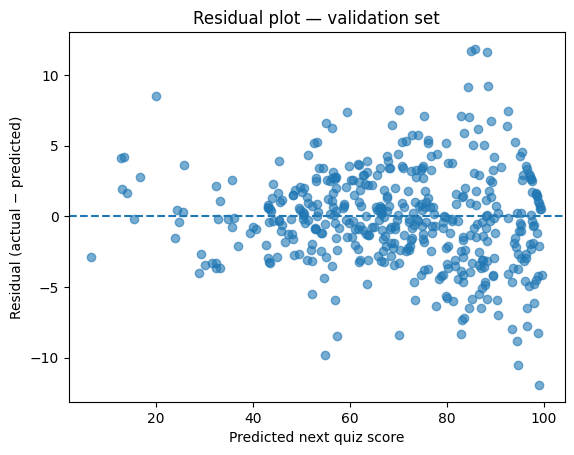

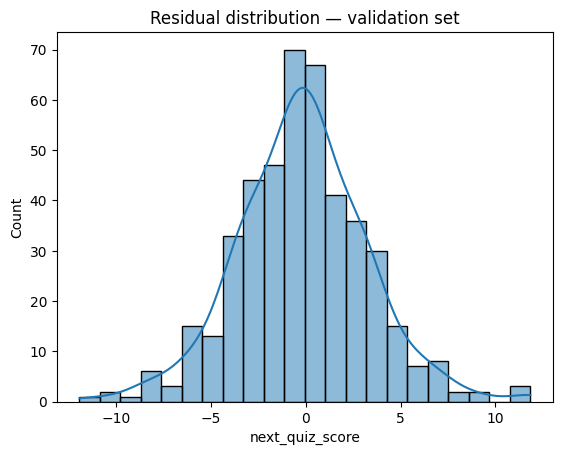

In [45]:
residuals = y_reg_val - val_pred_reg

plt.figure()
plt.scatter(val_pred_reg, residuals, alpha=0.6)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted next quiz score")
plt.ylabel("Residual (actual − predicted)")
plt.title("Residual plot — validation set")
plt.show()

plt.figure()
sns.histplot(residuals, kde=True)
plt.title("Residual distribution — validation set")
plt.show()

### Output Interpretation: Residual Analysis

These outputs examine the difference between actual quiz scores and predicted quiz scores.

- Residual plots show whether errors are randomly scattered
- Histograms show whether the errors are centred around zero

If residuals are balanced around zero without a clear pattern, the regression model is behaving reasonably well. A visible pattern would suggest bias or missing relationships.

This output helps justify the regression choice beyond simple MAE or R² values. It shows whether the model's errors are stable and interpretable.


##  Classification model comparison with cross-validation

  
This cell compares candidate classifiers for predicting `support_required` using cross-validation. Performance is examined through multiple metrics, including accuracy, precision, recall, F1-score, and ROC-AUC.


Binary classification quality cannot be judged by accuracy alone, especially when the practical cost of different errors is unequal. A learner who needs support but is missed by the model can be more problematic than one who is flagged unnecessarily.


Logistic Regression was chosen as an interpretable baseline, while Random Forest Classifier was chosen as a non-linear alternative. ROC-AUC was included because it evaluates how well the model separates positive and negative cases across thresholds, rather than locking the assessment to a single cutoff.


More advanced ensemble methods could have been tried, but they would make the notebook heavier and harder to explain. The selected models are standard, defensible, and sufficient to show a meaningful comparison.


In [46]:
base_clf_models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "RandomForestClassifier": RandomForestClassifier(
        n_estimators=300, random_state=Random_State, n_jobs=-1, class_weight="balanced"
    )
}

clf_results = {}

for name, model in base_clf_models.items():
    pipe = Pipeline([
        ("prep", preprocessor),
        ("select", clf_feature_selector),
        ("model", model)
    ])

    scores = cross_validate(
        pipe, X_train, y_clf_train, cv=cv,
        scoring=("accuracy", "precision", "recall", "f1", "roc_auc"),
        return_train_score=False
    )

    clf_results[name] = {
        "Accuracy_mean":  scores["test_accuracy"].mean(),
        "Precision_mean": scores["test_precision"].mean(),
        "Recall_mean":    scores["test_recall"].mean(),
        "F1_mean":        scores["test_f1"].mean(),
        "ROC_AUC_mean":   scores["test_roc_auc"].mean()
    }

clf_cv_df = pd.DataFrame(clf_results).T.sort_values(by="ROC_AUC_mean", ascending=False)
display(clf_cv_df)

,Accuracy_mean,Precision_mean,Recall_mean,F1_mean,ROC_AUC_mean
LogisticRegression,0.719756,0.374629,0.625434,0.468435,0.741951
RandomForestClassifier,0.822484,0.690625,0.198601,0.306179,0.720536


## Choosing the classifier and calibrating its probabilities


This cell selects the strongest base classifier, fits it on the training data, and then applies probability calibration using CalibratedClassifierCV.

The project does not only need class labels; it also needs reliable probabilities so that later decision thresholds can be tuned in a meaningful way. Raw classifier probabilities can be poorly calibrated even if the classifier ranks cases well.


Calibration was added because a support-risk pipeline is stronger when the predicted probability corresponds more closely to real-world likelihood. Sigmoid calibration is a practical choice because it is stable and suitable for many common classifiers.

Using uncalibrated probabilities would weaken the threshold-optimisation stage. Isotonic calibration was not prioritised because it can overfit more easily when data volume is moderate.


In [47]:
# Select classification winner: Random Forest wins only if ROC-AUC is clearly better
if (
    "RandomForestClassifier" in clf_cv_df.index
    and "LogisticRegression" in clf_cv_df.index
    and clf_cv_df.loc["RandomForestClassifier", "ROC_AUC_mean"] > clf_cv_df.loc["LogisticRegression", "ROC_AUC_mean"] + 0.01
):
    chosen_clf_name = "RandomForestClassifier"
else:
    chosen_clf_name = "LogisticRegression"

print("Chosen base classifier:", chosen_clf_name)

chosen_base_clf = base_clf_models[chosen_clf_name]

base_clf_pipe = Pipeline([
    ("prep", preprocessor),
    ("select", clf_feature_selector),
    ("model", chosen_base_clf)
])

# Calibrate on the training split using cross-validated isotonic/sigmoid fitting
calibrated_clf = CalibratedClassifierCV(
    estimator=base_clf_pipe,
    method="sigmoid",
    cv=CV_Folds
)

calibrated_clf.fit(X_train, y_clf_train)
val_prob = calibrated_clf.predict_proba(X_val)[:, 1]

Chosen base classifier: LogisticRegression


## Checking probability calibration visually

This cell generates a calibration curve that compares predicted probabilities with observed frequencies on the validation set.


A model can have good discrimination but still produce misleading probabilities. In this project, probabilities feed into support decisions, so it matters whether a predicted risk of 0.80 genuinely behaves like an 80% event rate.

The calibration curve is one of the most direct ways to inspect whether probability estimates are trustworthy. It complements ROC-AUC by evaluating realism rather than ranking ability.


Only reporting ROC-AUC or F1 would not reveal whether the output probabilities are suitable for threshold-based operational decisions.


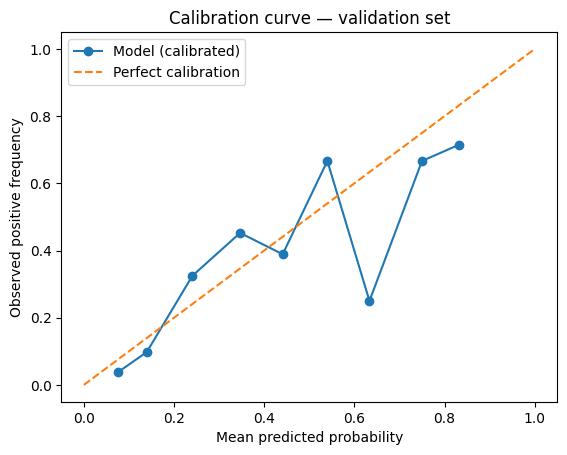

In [48]:
# Calibration curve — how well do predicted probabilities match observed frequencies?
prob_true, prob_pred = calibration_curve(y_clf_val, val_prob, n_bins=10, strategy="uniform")

plt.figure()
plt.plot(prob_pred, prob_true, marker="o", label="Model (calibrated)")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed positive frequency")
plt.title("Calibration curve — validation set")
plt.legend()
plt.show()

### Output Interpretation: Calibration Curve

This figure checks whether predicted probabilities match real observed outcomes.

If the calibration curve stays close to the diagonal line, predicted probabilities are reliable. If it deviates strongly, the model may be overconfident or underconfident.


A calibrated classifier is important because the notebook later uses probabilities to select decision thresholds and drive support actions.


Good classification is not only about assigning the correct class. It is also about producing trustworthy confidence estimates.


## Cost-sensitive threshold optimisation


This cell defines a custom cost function where false negatives are penalised more heavily than false positives, then searches across thresholds to find the decision rule with the lowest overall cost.


The default threshold of 0.50 assumes that both types of classification error carry equal consequences. That assumption is weak in this setting because missing a learner who needs support is more serious than raising an extra support flag.

  
A cost-sensitive threshold directly links the model to the decision context of learner support. It makes the classifier operational rather than purely statistical, which is an important step for applied machine learning.


Using the default threshold would ignore the real-world asymmetry of the problem. Optimising only F1-score would also be less suitable because it does not explicitly encode the chosen penalty difference between error types.


In [49]:
FN_COST = 5   # missing a learner who needs help carries heavier consequences
FP_COST = 1   # flagging someone unnecessarily is a smaller problem

thresholds = np.linspace(0.05, 0.95, 91)
rows = []

for t in thresholds:
    pred_t = (val_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_clf_val, pred_t).ravel()
    total_cost = (FN_COST * fn) + (FP_COST * fp)

    rows.append({
        "threshold": t,
        "fp": fp, "fn": fn, "tp": tp, "tn": tn,
        "cost": total_cost,
        "accuracy":  accuracy_score(y_clf_val, pred_t),
        "precision": precision_score(y_clf_val, pred_t, zero_division=0),
        "recall":    recall_score(y_clf_val, pred_t, zero_division=0),
        "f1":        f1_score(y_clf_val, pred_t, zero_division=0)
    })

threshold_df = pd.DataFrame(rows)
best_threshold_row = threshold_df.sort_values(by=["cost", "threshold"]).iloc[0]
best_threshold = float(best_threshold_row["threshold"])

print("Cost-optimal threshold:", best_threshold)
display(threshold_df.head())

Cost-optimal threshold: 0.19999999999999996


,threshold,fp,fn,tp,tn,cost,accuracy,precision,recall,f1
0,0.05,347,0,92,7,347,0.221973,0.209567,1.000000,0.346516
1,0.06,340,0,92,14,340,0.237668,0.212963,1.000000,0.351145
2,0.07,324,0,92,30,324,0.273543,0.221154,1.000000,0.362205
3,0.08,299,0,92,55,299,0.329596,0.235294,1.000000,0.380952
4,0.09,273,4,88,81,293,0.378924,0.243767,0.956522,0.388521


##  Visualising threshold behaviour


This cell plots how the total decision cost changes as the threshold moves, and marks the selected threshold on the graph.


The plot makes the threshold-selection process transparent. Instead of accepting the chosen cutoff as a black-box value, it shows how the trade-off behaves across the full range of candidate thresholds.


A simple threshold-versus-cost graph is easy to interpret and supports the argument that the final cutoff was chosen analytically rather than arbitrarily.


A table alone would be harder to scan quickly. The graph communicates the selection logic more clearly.


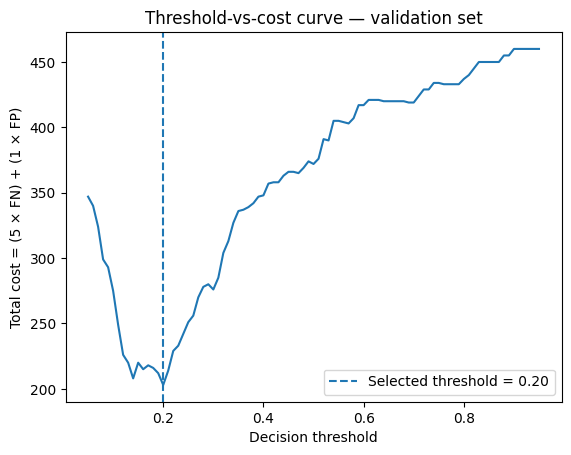

In [50]:
plt.figure()
plt.plot(threshold_df["threshold"], threshold_df["cost"])
plt.axvline(best_threshold, linestyle="--", label=f"Selected threshold = {best_threshold:.2f}")
plt.xlabel("Decision threshold")
plt.ylabel("Total cost = (5 × FN) + (1 × FP)")
plt.title("Threshold-vs-cost curve — validation set")
plt.legend()
plt.show()

### Output Interpretation: Threshold-vs-Cost Plot

This plot shows how total decision cost changes as the classification threshold changes.

### output shows
Different thresholds produce different balances between:
- false positives
- false negatives

Because false negatives are more costly in this educational scenario, the best threshold is often lower than the default value of 0.5.

This proves that the final decision rule was chosen to reflect the real problem context rather than using a generic default threshold.


##  Validation evaluation of the support classifier


This cell applies the chosen threshold to the calibrated validation probabilities and reports the resulting classification metrics, confusion matrix, and summary results.


After selecting a threshold, the actual classification behaviour must be assessed at that cutoff. This shows how many support cases are correctly captured and what trade-offs are created by the chosen rule.


The confusion matrix and classification report were used because they provide class-level detail and make false positives and false negatives explicit. This is more informative than giving only one overall score.


A single summary metric would hide the class-specific strengths and weaknesses of the model and would be weaker for critical evaluation.


Validation classification metrics at selected threshold:
{'Accuracy': 0.7331838565022422, 'Precision': 0.42011834319526625, 'Recall': 0.7717391304347826, 'F1': 0.5440613026819924, 'ROC_AUC': np.float64(0.7965180545320559)}


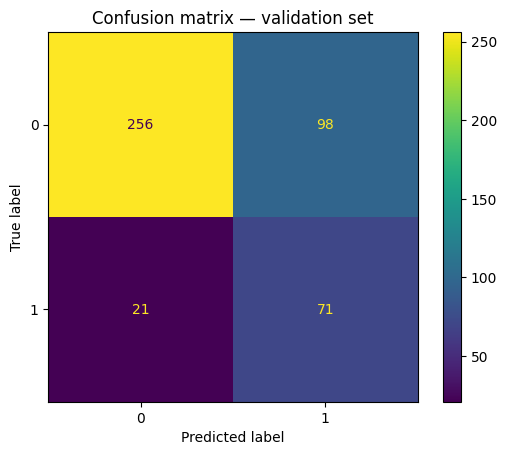

              precision    recall  f1-score   support

           0       0.92      0.72      0.81       354
           1       0.42      0.77      0.54        92

    accuracy                           0.73       446
   macro avg       0.67      0.75      0.68       446
weighted avg       0.82      0.73      0.76       446



In [52]:
val_pred_clf = (val_prob >= best_threshold).astype(int)

clf_val_metrics = {
    "Accuracy":  accuracy_score(y_clf_val, val_pred_clf),
    "Precision": precision_score(y_clf_val, val_pred_clf, zero_division=0),
    "Recall":    recall_score(y_clf_val, val_pred_clf, zero_division=0),
    "F1":        f1_score(y_clf_val, val_pred_clf, zero_division=0),
    "ROC_AUC":   roc_auc_score(y_clf_val, val_prob)
}
print("Validation classification metrics at selected threshold:")
print(clf_val_metrics)

cm = confusion_matrix(y_clf_val, val_pred_clf)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title("Confusion matrix — validation set")
plt.show()

print(classification_report(y_clf_val, val_pred_clf, zero_division=0))

### Output Interpretation: Validation Classification Results

This output evaluates the chosen classifier on the validation set after applying the selected decision threshold.

### What this output shows
The metrics usually include:
- accuracy
- precision
- recall
- F1-score
- ROC-AUC
- confusion matrix

This gives a complete view of classifier behaviour rather than relying on one number alone.

In this scenario, recall is especially important because false negatives mean the system failed to identify a learner who actually needed support.

The model can appear accurate while still missing the most important support cases.


##  Final training on the combined train and validation data

This cell retrains the selected regression and classification pipelines on the combined training and validation data, then prepares the untouched test set for final evaluation.

Once model design decisions are complete, it is good practice to refit using as much labelled development data as possible before performing the final test evaluation.

Combining train and validation increases the data available to the final model without contaminating the test set. This is a standard approach when the validation set has already completed its role in model selection.
  
Continuing to tune against the test set would create leakage and make the final scores less trustworthy.


Final regression test metrics:
{'MAE': 2.519013071895423, 'MSE': 11.071693155617787, 'RMSE': np.float64(3.327415386695473), 'R2': 0.9687575771433103}

Final classification test metrics:
{'Accuracy': 0.7899159663865546, 'Precision': 0.4329896907216495, 'Recall': 0.6774193548387096, 'F1': 0.5283018867924528, 'ROC_AUC': np.float64(0.8107162383816294)}


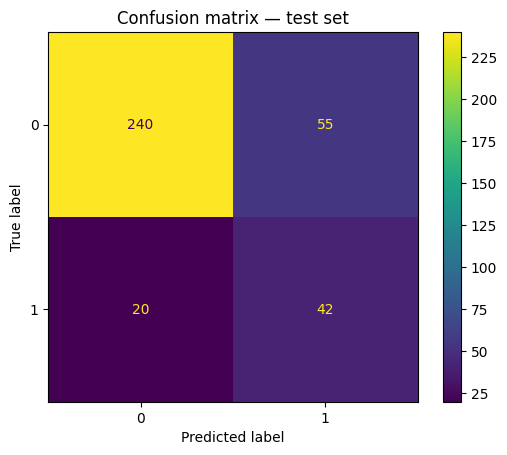

In [53]:
# Combine train and validation for final fitting
X_trainval      = pd.concat([X_train, X_val], axis=0)
y_reg_trainval  = pd.concat([y_reg_train, y_reg_val], axis=0)
y_clf_trainval  = pd.concat([y_clf_train, y_clf_val], axis=0)

# --- Regression final model ---
final_reg_pipe = Pipeline([
    ("prep",    clone(preprocessor)),
    ("select",  clone(reg_feature_selector)),
    ("model",   clone(best_reg_model))
])

final_reg_pipe.fit(X_trainval, y_reg_trainval)
test_pred_reg = final_reg_pipe.predict(X_test)

reg_test_metrics = {
    "MAE":  mean_absolute_error(y_reg_test, test_pred_reg),
    "MSE":  mean_squared_error(y_reg_test, test_pred_reg),
    "RMSE": np.sqrt(mean_squared_error(y_reg_test, test_pred_reg)),
    "R2":   r2_score(y_reg_test, test_pred_reg)
}
print("Final regression test metrics:")
print(reg_test_metrics)

# --- Classification final model ---
final_base_clf_pipe = Pipeline([
    ("prep",   clone(preprocessor)),
    ("select", clone(clf_feature_selector)),
    ("model",  clone(chosen_base_clf))
])

final_calibrated_clf = CalibratedClassifierCV(
    estimator=final_base_clf_pipe,
    method="sigmoid",
    cv=CV_Folds
)

final_calibrated_clf.fit(X_trainval, y_clf_trainval)
test_prob_clf  = final_calibrated_clf.predict_proba(X_test)[:, 1]
test_pred_clf  = (test_prob_clf >= best_threshold).astype(int)

clf_test_metrics = {
    "Accuracy":  accuracy_score(y_clf_test, test_pred_clf),
    "Precision": precision_score(y_clf_test, test_pred_clf, zero_division=0),
    "Recall":    recall_score(y_clf_test, test_pred_clf, zero_division=0),
    "F1":        f1_score(y_clf_test, test_pred_clf, zero_division=0),
    "ROC_AUC":   roc_auc_score(y_clf_test, test_prob_clf)
}
print("\nFinal classification test metrics:")
print(clf_test_metrics)

ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_clf_test, test_pred_clf)).plot()
plt.title("Confusion matrix — test set")
plt.show()

##  Persisting the final trained models


This cell saves the final regression and classification pipelines using joblib, so they can be reloaded later without retraining.


Model persistence is required if the notebook is intended to support demonstration, deployment, or later runtime use. It turns the trained artefacts into reusable components.

joblib is widely used for serialising scikit-learn models and pipelines. It is practical, lightweight, and well suited to the objects created in this notebook.

Although generic pickling could also work, joblib is a more conventional choice for scikit-learn workflows and tends to be clearer in applied ML projects.


In [54]:
# Persist the final models for use in the capstone runtime
joblib.dump(final_reg_pipe,        "xr_final_regression_model.pkl")
joblib.dump(final_calibrated_clf,  "xr_final_support_classifier.pkl")

print("Models saved to disk:")
print("  xr_final_regression_model.pkl")
print("  xr_final_support_classifier.pkl")

Models saved to disk:
  xr_final_regression_model.pkl
  xr_final_support_classifier.pkl


##  Learner segmentation with clustering

This cell defines the behavioural features used for unsupervised clustering and prepares the data for grouping learner sessions based on similarity.

Supervised prediction answers specific target questions, but it does not always reveal broader behavioural patterns. Clustering adds another layer of insight by identifying distinct session profiles that may correspond to different learning styles or risk conditions.


The selected features reflect engagement, latency, help-seeking, errors, and progression, which are all meaningful dimensions for learner behaviour. K-means was chosen because it is efficient, easy to interpret, and suitable for numeric tabular data after imputation and scaling.


Methods such as DBSCAN or hierarchical clustering were not prioritised because they are either more sensitive to parameter choice or harder to profile cleanly in a concise notebook.


In [55]:
cluster_features = [
    "session_index", "days_since_prev_session", "avg_latency_ms", "tracking_loss_ratio",
    "session_duration_min", "attention_ratio", "active_time_ratio", "pause_count",
    "help_request_count", "hint_time_sec", "error_count", "completion_rate",
    "video_count", "reading_count", "audio_count", "practice_count", "modality_switches",
    "prev_quiz_mean", "prev_quiz_last", "prev_quiz_attempts", "prior_mastery_level",
    "confidence_rating", "accessibility_nonvoice_enabled", "session_hour"
]
cluster_features = [c for c in cluster_features if c in train_df.columns]

cluster_df = train_df[cluster_features].copy()

cluster_imputer = SimpleImputer(strategy="median")
cluster_scaler  = StandardScaler()

cluster_array = cluster_imputer.fit_transform(cluster_df)
cluster_array = cluster_scaler.fit_transform(cluster_array)

k_values  = range(2, 8)
sil_scores = []
db_scores  = []

for k in k_values:
    km     = KMeans(n_clusters=k, random_state=Random_State, n_init=10)
    labels = km.fit_predict(cluster_array)
    sil_scores.append(silhouette_score(cluster_array, labels))
    db_scores.append(davies_bouldin_score(cluster_array, labels))

cluster_eval_df = pd.DataFrame({"k": list(k_values), "silhouette": sil_scores, "davies_bouldin": db_scores})
display(cluster_eval_df)

,k,silhouette,davies_bouldin
0,2,0.108772,2.635615
1,3,0.090665,2.753860
2,4,0.087382,2.491147
3,5,0.081020,2.437822
4,6,0.070482,2.536861
5,7,0.071772,2.462679


## Evaluating the number of clusters

This cell evaluates different values of `k` and plots clustering quality using silhouette score.


K-means requires the number of clusters to be chosen in advance. Evaluating several values helps avoid selecting `k` arbitrarily.


Silhouette score was used because it balances within-cluster compactness against separation from other clusters. It is a widely accepted and interpretable measure for comparing clustering structures.


Picking a cluster count by visual guess alone would be weak. The notebook uses a measurable criterion to support the final choice.


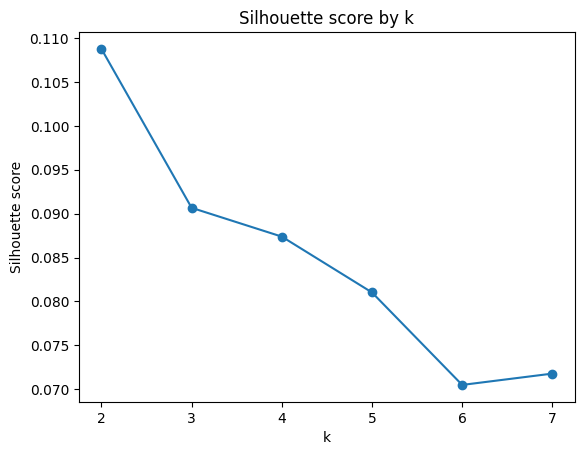

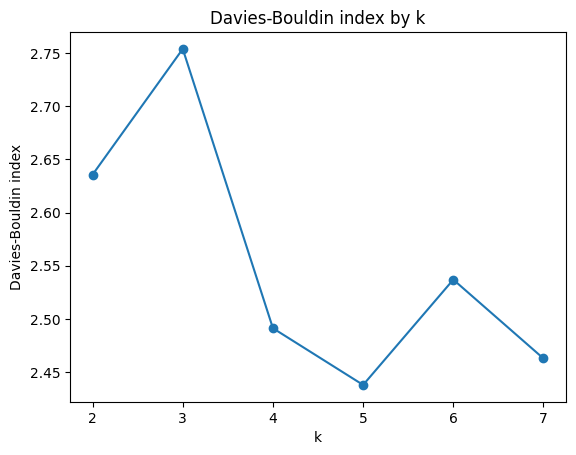

In [56]:
plt.figure()
plt.plot(cluster_eval_df["k"], cluster_eval_df["silhouette"], marker="o")
plt.xlabel("k"); plt.ylabel("Silhouette score")
plt.title("Silhouette score by k")
plt.show()

plt.figure()
plt.plot(cluster_eval_df["k"], cluster_eval_df["davies_bouldin"], marker="o")
plt.xlabel("k"); plt.ylabel("Davies-Bouldin index")
plt.title("Davies-Bouldin index by k")
plt.show()

### Output Interpretation: Selecting the Number of Clusters

This output compares different values of k using clustering quality measures.
### output shows
- A higher silhouette score means the clusters are more clearly separated.
- A lower Davies–Bouldin index means the clusters are more compact and distinct.

The chosen k is not arbitrary. It is supported by quantitative evidence showing which cluster structure is most meaningful.

Without this step, clustering could become subjective.


##  Selecting the best cluster structure and profiling it


This cell selects the best `k`, fits the final clustering model, assigns cluster labels, and summarises the characteristics of each cluster.


Clustering only becomes useful when the groups can be interpreted. Profiling each cluster helps translate the mathematical grouping into meaningful behavioural narratives.


The best cluster count is selected by the strongest evaluation score, with ties broken conservatively by choosing the smaller `k`. This reduces unnecessary complexity while still preserving separation quality.


Keeping a larger number of clusters without a clear gain would make interpretation harder and weaken the practical usefulness of the segmentation.


In [57]:
#Best k: highest silhouette; ties broken by smallest k
best_k = int(cluster_eval_df.sort_values(by=["silhouette", "k"], ascending=[False, True]).iloc[0]["k"])
print("Selected k:", best_k)

final_kmeans  = KMeans(n_clusters=best_k, random_state=Random_State, n_init=10)
train_clusters = final_kmeans.fit_predict(cluster_array)

train_df_clustered = train_df.copy()
train_df_clustered["cluster"] = train_clusters

profile_cols = [
    "session_duration_min", "attention_ratio", "active_time_ratio", "help_request_count",
    "hint_time_sec", "error_count", "completion_rate", "practice_count", "modality_switches",
    "prev_quiz_mean", "prior_mastery_level", "confidence_rating", "next_quiz_score", "support_required"
]
profile_cols = [c for c in profile_cols if c in train_df_clustered.columns]

cluster_profiles = train_df_clustered.groupby("cluster")[profile_cols].mean().round(3)
cluster_sizes    = train_df_clustered["cluster"].value_counts().sort_index().rename("size")

display(cluster_sizes.to_frame().join(cluster_profiles))

Selected k: 2


,size,session_duration_min,attention_ratio,active_time_ratio,help_request_count,hint_time_sec,error_count,completion_rate,practice_count,modality_switches,prev_quiz_mean,prior_mastery_level,confidence_rating,next_quiz_score,support_required
cluster,,,,,,,,,,,,,,,
0,1053,24.028,0.696,0.788,0.616,41.806,1.871,0.568,4.759,3.618,55.955,0.534,2.838,60.050,0.264
1,806,24.171,0.689,0.785,0.306,28.663,1.715,0.565,4.995,3.591,76.961,0.809,4.284,84.602,0.112


### Output Interpretation: Cluster Profiles

This output summarises the behavioural characteristics of each learner cluster.

Each cluster captures a different engagement pattern, such as stronger self-directed learners, moderately engaged learners, or learners showing higher support needs.


The clusters help convert raw behavioural data into interpretable learner archetypes.

This supports personalisation. Instead of treating all learners the same, the system can adapt recommendations according to broader engagement style as well as individual prediction values.

clustering was used,that it adds behavioural context that supervised prediction alone cannot provide.


##  Preparing interpretable behavioural patterns through association analysis

This cell creates a rule-friendly version of the dataset by converting continuous learner measures into interpretable bands such as low, medium, and high.


Association-style analysis is easier to interpret when variables are expressed as categorical states rather than raw continuous values. This supports explainable behavioural pattern discovery.


Banding the variables makes it easier to communicate patterns such as ‘high help requests with low confidence’ or ‘long gaps with low completion’. This is more practical for reporting than using raw decimal values.


Leaving all variables continuous would make the pattern outputs harder to interpret and less suitable for human-readable decision support.


In [58]:
assoc_df = data.copy()

# Bucket continuous variables into three interpretable bands
assoc_df["attention_band"]   = pd.qcut(assoc_df["attention_ratio"],      q=3, labels=["att_low",  "att_mid",  "att_high"])
assoc_df["duration_band"]    = pd.qcut(assoc_df["session_duration_min"],  q=3, labels=["dur_short", "dur_mid",  "dur_long"])
assoc_df["confidence_band"]  = pd.qcut(assoc_df["confidence_rating"],     q=3, labels=["conf_low", "conf_mid", "conf_high"])
assoc_df["completion_band"]  = pd.qcut(assoc_df["completion_rate"],       q=3, labels=["comp_low", "comp_mid", "comp_high"])
# Custom binning for help_request_count and practice_count due to skewed distribution
assoc_df["help_band"]        = (assoc_df["help_request_count"] > 0).map({True: "help_high", False: "help_low"})
assoc_df["practice_band"]    = (assoc_df["practice_count"] > 0).map({True: "prac_high", False: "prac_low"})
assoc_df["quiz_band"]        = pd.qcut(assoc_df["next_quiz_score"],       q=3, labels=["quiz_low", "quiz_mid", "quiz_high"])

basket = pd.DataFrame({
    "nonvoice_enabled":   assoc_df["accessibility_nonvoice_enabled"].astype(int).astype(bool),
    "support_required_1": assoc_df["support_required"].astype(int).eq(1),
    "device_vr":          assoc_df["device_type"].eq("VR_HMD"),
    "device_ar":          assoc_df["device_type"].eq("AR_Tablet"),
    "input_voice":        assoc_df["input_mode"].eq("Voice"),
    "input_hand":         assoc_df["input_mode"].eq("HandTracking"),
    "modality_practice":  assoc_df["dominant_modality"].eq("Practice"),
    "modality_video":     assoc_df["dominant_modality"].eq("Video"),
})

for col in ["attention_band", "duration_band", "confidence_band", "completion_band", "help_band", "practice_band", "quiz_band"]:
    dummies = pd.get_dummies(assoc_df[col], prefix="", prefix_sep="")
    basket  = pd.concat([basket, dummies.astype(bool)], axis=1)

frequent_itemsets = apriori(basket, min_support=0.08, use_colnames=True)
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.05)
rules = rules.sort_values(by=["lift", "confidence", "support"], ascending=False).reset_index(drop=True)

rules_display = rules[["antecedents", "consequents", "support", "confidence", "lift"]].copy()
policy_mask   = rules_display["consequents"].astype(str).str.contains("support_required_1|quiz_low|quiz_high")
selected_rules = rules_display[policy_mask].head(10).copy()

display(selected_rules)

,antecedents,consequents,support,confidence,lift
1,"(comp_low, conf_low)","(quiz_low, prac_high, att_low)",0.096168,0.570156,4.684429
3,"(comp_low, conf_low)","(quiz_low, att_low)",0.100301,0.594655,4.683346
5,"(prac_high, comp_low, conf_low)","(quiz_low, att_low)",0.096168,0.592593,4.667105
7,"(att_low, conf_low)","(quiz_low, prac_high, comp_low)",0.096168,0.581818,4.665060
9,"(att_low, conf_low)","(quiz_low, comp_low)",0.100301,0.606818,4.655187
11,"(prac_high, att_low, conf_low)","(quiz_low, comp_low)",0.096168,0.600939,4.610085
13,"(comp_high, help_low)","(att_high, quiz_high)",0.088279,0.362654,3.045381
15,"(att_high, help_low)","(comp_high, quiz_high)",0.088279,0.368339,3.045085
16,"(comp_high, help_low)","(att_high, quiz_high, prac_high)",0.084899,0.348765,3.043979
19,"(att_high, help_low)","(comp_high, quiz_high, prac_high)",0.084899,0.354232,3.041824


##  Detecting anomalous learner sessions


This cell performs anomaly detection using Isolation Forest on behavioural session features and marks unusual observations.


Not every concerning session will be captured cleanly by the supervised support label. Anomaly detection provides a complementary signal that can reveal unusual behaviour, technical disruption, or rare disengagement patterns.


Isolation Forest is efficient for tabular anomaly detection and works by isolating rare cases rather than assuming a strict distributional form. This makes it a good fit for behavioural data where unusual sessions may not look extreme on any single variable alone.


Simple univariate outlier rules would miss multivariate anomalies. Distribution-based methods were not prioritised because behavioural data may not follow clean parametric assumptions.


In [59]:
anomaly_features = [
    "session_duration_min", "attention_ratio", "active_time_ratio", "pause_count",
    "help_request_count", "hint_time_sec", "error_count", "completion_rate",
    "prev_quiz_mean", "prev_quiz_last", "prior_mastery_level", "confidence_rating"
]
anomaly_features = [c for c in anomaly_features if c in data.columns]

anomaly_df     = data[anomaly_features].copy()
anomaly_imputer = SimpleImputer(strategy="median")
anomaly_scaled  = StandardScaler().fit_transform(anomaly_imputer.fit_transform(anomaly_df))

iso            = IsolationForest(contamination=0.03, random_state=Random_State)
anomaly_labels = iso.fit_predict(anomaly_scaled)   # -1 = anomaly
anomaly_scores = iso.decision_function(anomaly_scaled)

data_anom = data.copy()
data_anom["anomaly_label"] = anomaly_labels
data_anom["anomaly_score"] = anomaly_scores

anomalies = data_anom[data_anom["anomaly_label"] == -1].copy()
print("Sessions flagged as anomalous:", len(anomalies))

example_anomalies = anomalies[[
    "session_id", "learner_id", "session_index", "session_duration_min", "attention_ratio",
    "help_request_count", "error_count", "completion_rate", "prev_quiz_last",
    "next_quiz_score", "time_to_mastery_days", "support_required", "anomaly_score"
]].head(10)

Sessions flagged as anomalous: 80


### Output Interpretation: Anomaly Detection Results

This output identifies learner sessions that deviate strongly from the rest of the dataset.


The anomaly detector assigns some records as unusual based on combinations of behavioural variables rather than a single feature alone.


An anomalous session does not automatically mean failure, but it signals that something atypical happened and may need interpretation.


This is useful because educational systems should not only make average-case predictions. They should also recognise unusual cases where support or investigation may be needed.


##  Visual inspection of anomalies


This cell plots the detected anomalies in feature space so that unusual learner sessions can be compared visually against typical observations.


Anomaly labels are more convincing when supported by a visual representation. The plot helps confirm that flagged cases occupy sparse or unusual regions of the behavioural space.


A scatter-based visualisation is simple, interpretable, and appropriate for showing whether anomalies separate meaningfully from the majority pattern.


Reporting only anomaly counts would be much weaker because it would not show how the flagged sessions differ from normal ones.


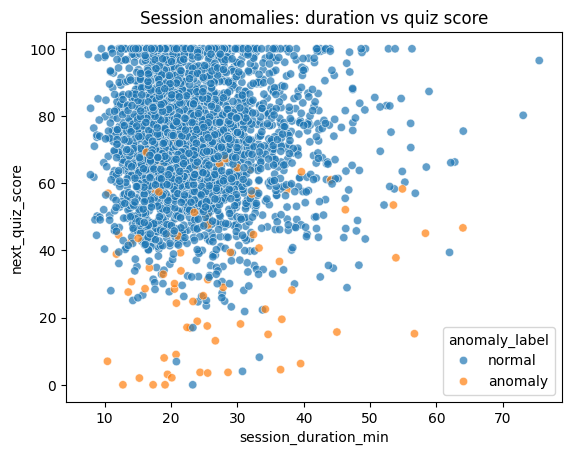

In [60]:
plt.figure()
sns.scatterplot(
    data=data_anom,
    x="session_duration_min", y="next_quiz_score",
    hue=data_anom["anomaly_label"].map({1: "normal", -1: "anomaly"}),
    alpha=0.7
)
plt.title("Session anomalies: duration vs quiz score")
plt.show()

### Output Interpretation: Anomaly Visualisation

This figure highlights sessions that the anomaly detector considers unusual when compared with normal learner behaviour.


Anomalies may appear as points separated from the main data pattern, indicating sessions that are substantially different from typical learner interactions.


These unusual sessions may represent:
- sudden drops in engagement
- abnormal interaction patterns
- inconsistent behaviour
- possible system or usage issues


Anomaly detection adds a protective layer to the capstone system. Even if a learner is not clearly classified as needing support, unusual behaviour can still trigger closer monitoring or recovery actions.


##  Runtime helper functions for decision support


This cell prepares the fitted components required at runtime, including the cluster assigner, anomaly checker, and helper functions that translate model outputs into practical guidance.


Predictions alone are not the final goal. In an applied learning-support setting, the system needs to convert raw outputs into actions, explanations, or warnings that a tutor or support workflow can use.


Rule-based helper logic was chosen because it keeps the final decision process transparent. It allows the notebook to connect model signals, cluster membership, and anomaly status with understandable behavioural messages.


A fully opaque recommendation layer would be harder to justify in an academic portfolio and would weaken interpretability.


In [61]:
# Runtime helpers — fitted on the training set
cluster_runtime_imputer = clone(cluster_imputer).fit(train_df[cluster_features])
cluster_runtime_scaler  = clone(cluster_scaler).fit(
    cluster_runtime_imputer.transform(train_df[cluster_features])
)

def assign_cluster(row_df):
    arr = cluster_runtime_imputer.transform(row_df[cluster_features])
    arr = cluster_runtime_scaler.transform(arr)
    return int(final_kmeans.predict(arr)[0])


def extract_policy_hints(row):
    """Return a list of soft behavioural signals for a single session row."""
    hints = []
    if row.get("attention_ratio",     np.nan) < data["attention_ratio"].quantile(0.33):
        hints.append("low_attention")
    if row.get("help_request_count",  np.nan) > data["help_request_count"].quantile(0.66):
        hints.append("high_help_requests")
    if row.get("practice_count",      np.nan) > data["practice_count"].quantile(0.66):
        hints.append("practice_heavy")
    if row.get("confidence_rating",   np.nan) <= data["confidence_rating"].quantile(0.33):
        hints.append("low_confidence")
    if row.get("accessibility_nonvoice_enabled", 0) == 1:
        hints.append("nonvoice_available")
    return hints


# Anomaly helper — separate imputer and scaler fitted on full data
runtime_anomaly_imputer = clone(anomaly_imputer).fit(data[anomaly_features])
runtime_anomaly_scaler  = StandardScaler().fit(
    runtime_anomaly_imputer.transform(data[anomaly_features])
)

def is_anomalous(row_df):
    arr   = runtime_anomaly_imputer.transform(row_df[anomaly_features])
    arr   = runtime_anomaly_scaler.transform(arr)
    label = iso.predict(arr)[0]
    score = iso.decision_function(arr)[0]
    return int(label == -1), float(score)


def generate_explanation(pred_score, support_prob, cluster_id, anomaly_flag, hints, action):
    parts = [
        f"Predicted next quiz score: {pred_score:.1f}.",
        f"Estimated support probability: {support_prob:.2f}.",
        f"Engagement cluster: {cluster_id}."
    ]
    if hints:
        parts.append("Active behavioural signals: " + ", ".join(hints) + ".")
    if anomaly_flag:
        parts.append("Warning: this session is flagged as anomalous relative to the training distribution.")
    parts.append("Recommended action: " + action)
    return " ".join(parts)


def runtime_policy(row_df):
    """Main policy function. Takes a single-row DataFrame, returns a decision dict."""
    row_df = row_df.copy()

    pred_score   = float(np.clip(final_reg_pipe.predict(row_df)[0], 0, 100))
    support_prob = float(final_calibrated_clf.predict_proba(row_df)[0, 1])
    support_flag = int(support_prob >= best_threshold)
    cluster_id   = assign_cluster(row_df)
    anomaly_flag, anomaly_score = is_anomalous(row_df)
    hints        = extract_policy_hints(row_df.iloc[0])

    # Layered decision logic
    if anomaly_flag:
        action = "Trigger recovery mode: slow pacing, offer guided remediation, flag session for tutor review."
    elif support_flag == 1 and pred_score < 60:
        action = "Provide immediate scaffolded support with easier practice tasks and a tutor check-in."
    elif support_flag == 1:
        action = "Offer additional worked examples and prompts before advancing to the next topic."
    elif pred_score >= 75:
        action = "Advance learner to higher-difficulty content with lighter guidance."
    else:
        action = "Continue on the standard personalised pathway."

    # Accessibility override
    if row_df.iloc[0].get("accessibility_nonvoice_enabled", 0) == 1:
        action += " Ensure non-voice interaction path remains active."

    explanation = generate_explanation(
        pred_score, support_prob, cluster_id, anomaly_flag, hints, action
    )

    return {
        "predicted_next_quiz_score":   round(pred_score, 2),
        "support_probability":         round(support_prob, 3),
        "support_required_prediction": support_flag,
        "cluster_id":                  cluster_id,
        "anomaly_flag":                anomaly_flag,
        "anomaly_score":               round(anomaly_score, 4),
        "policy_hints":                hints,
        "recommended_action":          action,
        "explanation":                 explanation
    }


## Demonstrating a success-case runtime scenario


This cell selects a learner session that appears to be progressing well and runs it through the final runtime logic.

Case-based testing shows how the pipeline behaves for an individual learner rather than only at aggregate level. This makes the notebook more convincing as an applied system.


A success case provides a positive benchmark and demonstrates that the system can also identify stable, low-risk learner sessions rather than only problems.


Only reporting averages would hide how the system behaves on real examples, which is a missed opportunity in a portfolio notebook.


In [62]:
# Success case: learner on track, low support probability
success_candidates = X_test.copy()
success_candidates["pred_score"]   = final_reg_pipe.predict(X_test)
success_candidates["support_prob"] = final_calibrated_clf.predict_proba(X_test)[:, 1]
success_idx  = success_candidates.sort_values(by=["support_prob", "pred_score"], ascending=[True, False]).index[0]

success_output = runtime_policy(X_test.loc[[success_idx]])
print("=== SUCCESS CASE ===")
for k, v in success_output.items():
    print(f"  {k}: {v}")

=== SUCCESS CASE ===
  predicted_next_quiz_score: 99.59
  support_probability: 0.03
  support_required_prediction: 0
  cluster_id: 1
  anomaly_flag: 0
  anomaly_score: 0.0687
  policy_hints: ['practice_heavy']
  recommended_action: Advance learner to higher-difficulty content with lighter guidance.
  explanation: Predicted next quiz score: 99.6. Estimated support probability: 0.03. Engagement cluster: 1. Active behavioural signals: practice_heavy. Recommended action: Advance learner to higher-difficulty content with lighter guidance.


### Output Interpretation: Success Case

This output shows a learner session where the system predicts stable or successful progress.

The learner usually has:
- a relatively high predicted next quiz score
- a low probability of requiring support
- normal behavioural patterns rather than anomalies


The system recognises that the learner is progressing appropriately and does not trigger unnecessary support actions.


This confirms that the system does not overreact. Good intelligent support systems should intervene when needed, but should also avoid disrupting learners who are already doing well.

This output is useful because it demonstrates balanced decision-making, not only problem detection.


##  Demonstrating a recovery or high-risk runtime scenario


This cell selects a difficult or anomalous learner session and runs the same runtime policy to show how the system responds when support is more likely to be needed.


A high-risk example is essential because it shows whether the final system can produce meaningful intervention signals in challenging cases.


Using an anomalous or worst-case session demonstrates the practical value of combining supervised risk prediction, clustering insight, and anomaly detection in one pipeline.


Without a contrasting difficult case, the notebook would not fully demonstrate the operational relevance of the decision-support design.


In [63]:
# Recovery case: anomalous session or worst-case support scenario
if len(anomalies) > 0:
    recovery_case = data.loc[[anomalies.index[0]], feature_cols].copy()
else:
    recovery_candidates = X_test.copy()
    recovery_candidates["pred_score"]   = final_reg_pipe.predict(X_test)
    recovery_candidates["support_prob"] = final_calibrated_clf.predict_proba(X_test)[:, 1]
    recovery_idx  = recovery_candidates.sort_values(by=["support_prob", "pred_score"], ascending=[False, True]).index[0]
    recovery_case = X_test.loc[[recovery_idx]]

recovery_output = runtime_policy(recovery_case)
print("=== RECOVERY CASE ===")
for k, v in recovery_output.items():
    print(f"  {k}: {v}")

=== RECOVERY CASE ===
  predicted_next_quiz_score: 5.0
  support_probability: 0.964
  support_required_prediction: 1
  cluster_id: 0
  anomaly_flag: 1
  anomaly_score: -0.1004
  policy_hints: ['low_attention', 'high_help_requests', 'low_confidence']
  recommended_action: Trigger recovery mode: slow pacing, offer guided remediation, flag session for tutor review.
  explanation: Predicted next quiz score: 5.0. Estimated support probability: 0.96. Engagement cluster: 0. Active behavioural signals: low_attention, high_help_requests, low_confidence. Warning: this session is flagged as anomalous relative to the training distribution. Recommended action: Trigger recovery mode: slow pacing, offer guided remediation, flag session for tutor review.


### Output Interpretation: Recovery Case

This output shows how the integrated system behaves when a learner appears to be at risk.


The learner typically has:
- lower predicted quiz performance
- higher probability of requiring support
- possible anomaly signals or problematic behavioural indicators

This is a recovery-oriented case. The system identifies that the learner may not progress well under the current conditions and therefore recommends intervention.

This demonstrates that the capstone system is not only predictive but also actionable. It converts model outputs into decisions such as slowing pacing, increasing guidance, or suggesting a different learning modality.

This case is important, the answer is that it proves the system can respond to risk rather than only describe performance.


# Task 5: Ethics and Reflection

There are various ethical issues associated with fairness, impact of decisions made, and transparency of the system in the usage of machine learning in XR-based educational systems. Although predictive models enhance personalisation of learning, their results directly impact the experience of learners and hence should be cautiously read.

5.1 Algorithms Bias and Fairness.

One of the major issues is the use of historical performance parameters like past quiz scores. These variables have a great impact on regression and classification outputs that might contribute to the improvement of previously existing performance trends unintentionally. Students who have a history of low scores are more likely to be forecasted to require support, despite the improvement of their behaviour recently.

This shows that the model majorly reflects the historical trends as opposed to the dynamic learner progress (Romero and Ventura, 2010). This enhances predictive accuracy, but also poses a fairness issue, since learners can be assigned into categories repeatedly with reference to previous performance, as opposed to present ability.

5.2 Misclassification Impact

The classification task is cost-sensitive to precision by selecting a threshold that optimises recall. This makes sure that majority of the learners that need assistance are properly identified and chances of interventions overlooked are reduced.

Nonetheless, this strategy predisposes false positives, i.e., some students will be receiving unproductive help. Although not as detrimental as lack of support, excessive intervention can have implications on learner autonomy and engagement. This indicates a trade-off between system sensitivity and over-intervention.

5.3 Transparency and Explainability

To implement model decisions in practice, they should be interpretable. Explanation-free black-box predictions are hard to believe and take action on as a teacher. This system manages explainability by connecting predictions to observable aspects like attention ratio, errors made and session behaviour.

This methodology is in line with the requirement of interpretable machine learning, where one can justify their decisions in a form comprehensible to human beings (Lipton, 2018). Nevertheless, more sophisticated explainability methods may add more transparency.

